In [1]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import textwrap
import nltk
import gensim.models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


from nltk.stem import PorterStemmer

from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

from sklearn.manifold import TSNE
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split





[nltk_data] Downloading package wordnet to /home/gertrude/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
df=pd.read_csv("fake_news_dataset.csv")

In [4]:
df.describe() #balanced classes

,id,label
count,20800.000000,20800.000000
mean,10399.500000,0.500625
std,6004.587135,0.500012
min,0.000000,0.000000
25%,5199.750000,0.000000
50%,10399.500000,1.000000
75%,15599.250000,1.000000
max,20799.000000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      20800 non-null  int64
 1   title   20242 non-null  str  
 2   author  18843 non-null  str  
 3   text    20761 non-null  str  
 4   label   20800 non-null  int64
dtypes: int64(2), str(3)
memory usage: 812.6 KB


In [6]:
df.head(10)

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1
5,5,Jackie Mason: Hollywood Would Love Trump if He...,Daniel Nussbaum,"In these trying times, Jackie Mason is the Voi...",0
6,6,Life: Life Of Luxury: Elton John’s 6 Favorite ...,NaN,Ever wonder how Britain’s most iconic pop pian...,1
7,7,Benoît Hamon Wins French Socialist Party’s Pre...,Alissa J. Rubin,"PARIS — France chose an idealistic, traditi...",0
8,8,Excerpts From a Draft Script for Donald Trump’...,NaN,Donald J. Trump is scheduled to make a highly ...,0
9,9,"A Back-Channel Plan for Ukraine and Russia, Co...",Megan Twohey and Scott Shane,A week before Michael T. Flynn resigned as nat...,0


Data Preparation Section

Cleaning

In [7]:
df=df.dropna(subset=["text"])

In [8]:
#df.info() #checking

In [9]:
#fake news

# first_sample=df["text"].iloc[0]
# first_label=df["label"].iloc[0]

# print(f"Label : {first_label}\n")
# print(textwrap.fill(first_sample, width=60))

In [10]:
#not fake news

# second_sample=df["text"].iloc[1]
# second_label=df["label"].iloc[1]

# print(f"Label : {second_label}\n")
# print(textwrap.fill(second_sample, width=60))

Pre-Processing

In [11]:
def to_lowercase(df): # be careful about using it : could mix Apple (the brand) and apple (the fruit)
    df["title"] = df["title"].str.lower()
    df["text"] = df["text"].str.lower()
    return df


#test
# df_bis=df.copy()
# df_bis=to_lowercase(df_bis)

# sample=df_bis["text"].iloc[0]
# print(textwrap.fill(sample, width=60))

In [12]:
#Delete punctuation
def delete_punctuation(df):
    df['text'] = df['text'].str.replace(r'[^\w\s]', '', regex=True)
    return df


#test
# df_bis=df.copy()
# df_bis=delete_punctuation(df_bis)

# sample=df_bis["text"].iloc[0]
# print(textwrap.fill(sample, width=60))

In [13]:
#Stemming

def stem_text(df):
    stemmer = PorterStemmer()
    words = df.split()
    stems = [stemmer.stem(word) for word in words]
    return " ".join(stems)


#test
# df_bis=df.copy()
# df_bis["text_stemmed"] = df_bis["text"].apply(stem_text)
# sample_stemmed=df_bis["text_stemmed"].iloc[0]
# print(textwrap.fill(sample_stemmed, width=60))

In [14]:
#Lemmatize dataset

def lemmatize(text):
    lemmatizer=WordNetLemmatizer()
    words=text.split()
    return " ".join(lemmatizer.lemmatize(w) for w in words)

#test
# df_bis=df.copy()
# df_bis["text_lemmatized"] = df_bis["text"].apply(lemmatize)
# sample_lemmatized=df_bis["text_lemmatized"].iloc[0]
# print(textwrap.fill(sample_lemmatized, width=60))

In [15]:
df=to_lowercase(df)
df=delete_punctuation(df)
df["text"]=df["text"].apply(lemmatize)

In [19]:
#Tokenisation
tokenized_texts = [text.split() for text in df["text"]]

print(tokenized_texts[0]) # tokenized_texts[0] = 1st tokenized article 
first_sample=df["text"].iloc[0]
print(first_sample)


['house', 'dem', 'aide', 'we', 'didnt', 'even', 'see', 'comeys', 'letter', 'until', 'jason', 'chaffetz', 'tweeted', 'it', 'by', 'darrell', 'lucus', 'on', 'october', '30', '2016', 'subscribe', 'jason', 'chaffetz', 'on', 'the', 'stump', 'in', 'american', 'fork', 'utah', 'image', 'courtesy', 'michael', 'jolley', 'available', 'under', 'a', 'creative', 'commonsby', 'license', 'with', 'apology', 'to', 'keith', 'olbermann', 'there', 'is', 'no', 'doubt', 'who', 'the', 'worst', 'person', 'in', 'the', 'world', 'is', 'this', 'weekfbi', 'director', 'james', 'comey', 'but', 'according', 'to', 'a', 'house', 'democratic', 'aide', 'it', 'look', 'like', 'we', 'also', 'know', 'who', 'the', 'secondworst', 'person', 'is', 'a', 'well', 'it', 'turn', 'out', 'that', 'when', 'comey', 'sent', 'his', 'nowinfamous', 'letter', 'announcing', 'that', 'the', 'fbi', 'wa', 'looking', 'into', 'email', 'that', 'may', 'be', 'related', 'to', 'hillary', 'clinton', 'email', 'server', 'the', 'ranking', 'democrat', 'on', 'the

Visualisation

In [17]:
#https://radimrehurek.com/gensim/models/word2vec.html
w2v_model = Word2Vec(sentences=tokenized_texts,vector_size=100,window=5,min_count=1,workers=4)
print(f"Vocabulaire : {len(w2v_model.wv)} mots")

Vocabulaire : 200496 mots


In [18]:
neighbors = w2v_model.wv.most_similar("death",topn=5)  #shows the most similar words in the texts to the selected term
for neighbor, score in neighbors:
    print(f"  {neighbor}:   distance cosine = {1-score:.4f}")

  murder:   distance cosine = 0.3024
  execution:   distance cosine = 0.3750
  disappearance:   distance cosine = 0.3910
  killing:   distance cosine = 0.4006
  injury:   distance cosine = 0.4058


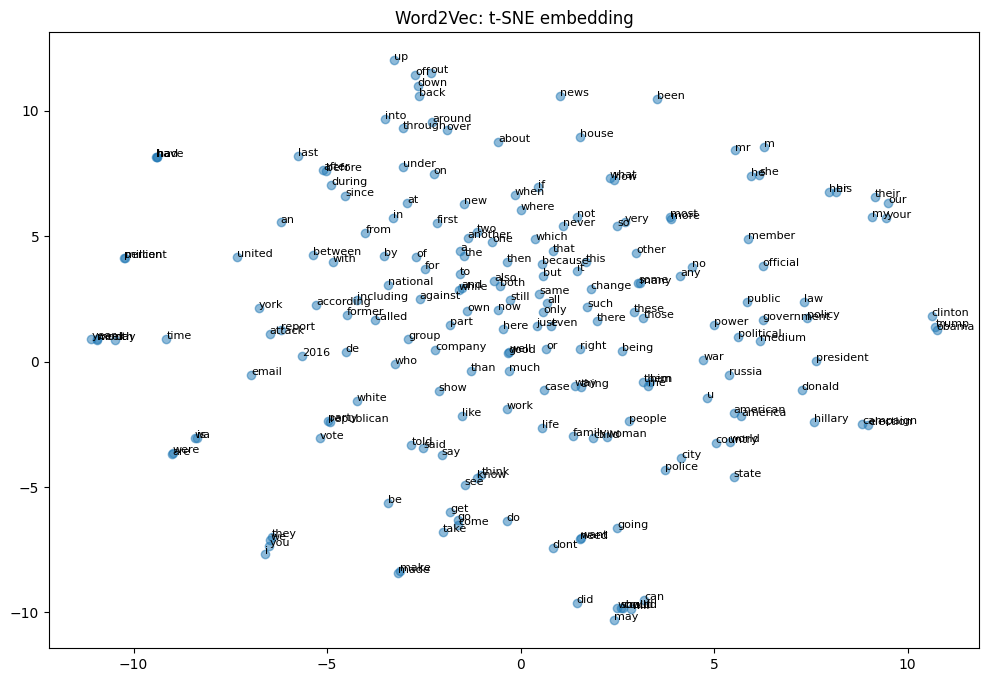

In [ ]:
words = list(w2v_model.wv.index_to_key[:200])  # 200 first words
vectors = np.array([w2v_model.wv[word] for word in words])

tsne = TSNE(n_components=2, random_state=42)
vectors_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(12,8))
plt.scatter(vectors_2d[:,0],vectors_2d[:,1],alpha=0.5)

for i, word in enumerate(words):
    plt.annotate(word,(vectors_2d[i,0], vectors_2d[i,1]),fontsize=8)

plt.title("Word2Vec: t-SNE embedding")
plt.show()